In [ ]:
from uspas_llrf.llrf_app.app import LLRFApp
from uspas_llrf.utils import calc_ps, plot_ps
from pprint import pprint
import matplotlib.pyplot as plt
import time

%load_ext autoreload
%autoreload 2

# Program bitstream file

In [ ]:
!make -C top/marble_zest/ system_config MARBLE_SERIAL=42 GIT_32BIT_ID=f37d78b7 FSET=USPAS

make: Entering directory '/home/qdu/work/uspas_llrf/top/marble_zest'
Makefile:44: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 42
openocd \
-c "adapter serial 000042;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_USPAS.f37d78b7.bit; exit"
Open On-Chip Debugger 0.12.0+dev-00519-gb6ee13720-dirty (2025-07-15-02:38)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Info : auto-selecting first available session transport "jtag". To override use 'transport select <transport>'.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] E

# Read Board Support info

In [5]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='USPAS', chan_keep=0b1011)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -24.8 mV
  Power      :      0.6 mW
  Vbus       :     11.9 V
  Current    :  -1062.3 mA
INA219 U17, FMC1:
  Vshunt     :     25.7 mV
  Power      :     55.1 mW
  Vbus       :     11.9 V
  Current    :    188.7 mA
INA219 U32, FMC2:
  Vshunt     :    -16.3 mV
  Power      :      1.1 mW
  Vbus       :     11.9 V
  Current    :    126.6 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11111111
  Temp       :    47 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    0 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    0 uW
  TxBias2    :    0 uA
  TxPwr2     :    0 

In [6]:
pprint(llrf.model.cal_factors)

LLRFCalibrations(rx_gain=2.834324316653029,
                 tx_gain=1.5484051512437746,
                 rx_phase_off_deg=65.64516888886018,
                 tx_phase_off_deg=-15.652173913043494,
                 rx_dds_omega_deg=62.608695652173914,
                 tx_dds_omega_deg=31.304347826086957,
                 cic_wfm_gain=(7.113197508351705+0j),
                 inlk_gain=(0.366054092653675+0j),
                 inlk_tx_gain=(0.10406174450444879+0.2008300504692065j),
                 rx_iq_gain=(1.7211517600548545+0j),
                 tx_iq_gain=(0.43258699669069506-0.8348550064332302j),
                 max_adc_input=31129.6,
                 max_dac_drive=31129.6,
                 max_amp_setpoint=20104.298913623985)


## Measure a snapshot of RF amplitude and phases

* In open loop, set `amp_setpoint` to drive DAC output level at 20000 counts.
* The scaling factor of `tx_gain` is applied, which is the ratio from `amp_setpoint` to DAC output.
* The `max_amp_setpoint` is the maximum value of `amp_setpoint` before saturation.

In [ ]:
llrf.init_open_loop_demo(2e4)

An array of calibrated, complex RF levels at base-band are available by `llrf.get_rfmon()` function, which applies the `inlk_gain` and `inlk_tx_gain` to ADC and DAC channels respectively.

In [12]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,7312,14,19975.189861,0.038452
adc1,3801,54728,10383.711250,150.314941
adc2,0,36366,0.000000,0.000000
adc3,3855,32260,10531.230431,88.604736
adc4,2,-49138,5.463673,-134.961548
adc5,2,-32458,5.463673,-89.148560
adc6,0,-65226,0.000000,-0.000000
adc7,2,36366,5.463673,99.882202
dac0,4523,22801,19996.533554,0.016121
dac1,4523,22801,19996.533554,0.016121


Confirm MO phase is aligned

In [13]:
mo_adc_chan = llrf.read_reg('prl_adc_chan')
fdbk_adc_chan = llrf.read_reg('fdbk_adc_chan')
mo_adc = f'adc{mo_adc_chan}'
fdbk_adc = f'adc{fdbk_adc_chan}'
print(f'MO ADC = {mo_adc}, FDBK ADC = {fdbk_adc}')

MO ADC = adc0, FDBK ADC = adc3


In [14]:
assert -0.2 < df_mon['Phs [deg]'][mo_adc] < 0.2

## Plot raw DAC / ADC data

In [15]:
df_sig = llrf.get_raw_bufs_df()

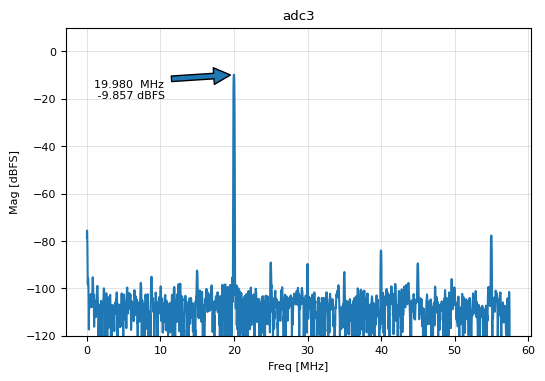

In [16]:
f, psd_dbfs = calc_ps(df_sig[fdbk_adc], fs_mhz=1e3/llrf.model.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title=fdbk_adc, annotate=True)

# Pulse mode test

In [17]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.model.DSP_CLK_CYCLE)
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 459 counts


<Axes: xlabel='Time [ns]'>

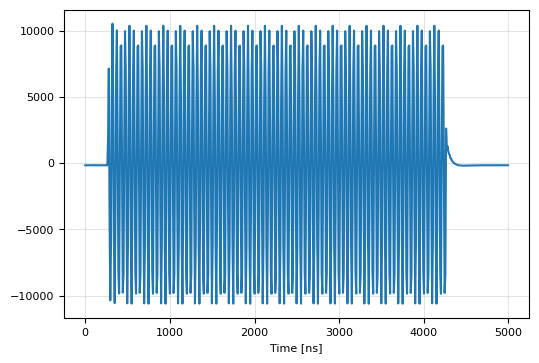

In [18]:
df_sig = llrf.get_raw_bufs_df()
df_sig[fdbk_adc].loc[:5000].plot()

In [26]:
df_iq = llrf.get_iq_wfms_df()

<Axes: xlabel='Time [ns]'>

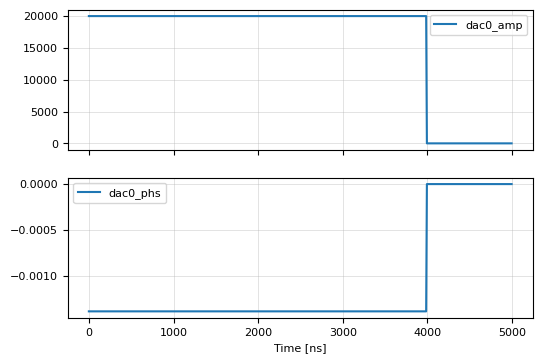

In [27]:
len_ns = 5000
fig, axes = plt.subplots(2, sharex=True)
df_iq[['dac0' + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[['dac0' + '_phs']].loc[:len_ns].plot(ax=axes[1])


<Axes: xlabel='Time [ns]'>

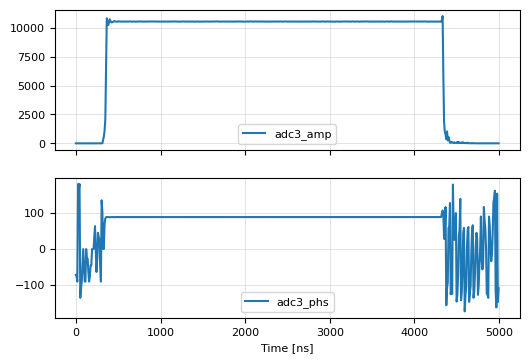

In [28]:
fig, axes = plt.subplots(2, sharex=True)
df_iq[[fdbk_adc + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[[fdbk_adc + '_phs']].loc[:len_ns].plot(ax=axes[1])


## Plot CIC circular buffer data

In [29]:
df_mp = llrf.get_cic_wfm_df()

<Axes: xlabel='Time [ns]'>

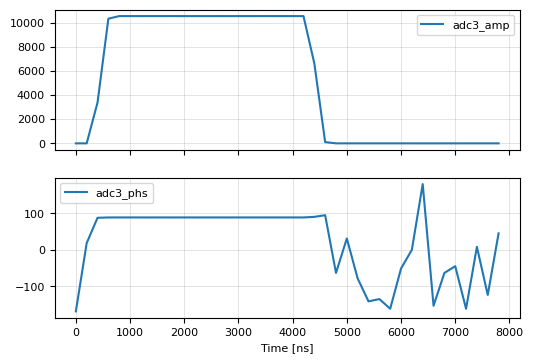

In [30]:
len_ns = 8000
fig, axes = plt.subplots(2, sharex=True)
df_mp[fdbk_adc + '_amp'].loc[:len_ns].plot(ax=axes[0], legend=True)
df_mp[fdbk_adc + '_phs'].loc[:len_ns].plot(ax=axes[1], legend=True)